In [20]:
#run this everytime an edit is made in utils.py so that we can use the helper functions in this Python Notebook
import importlib
import utils2
importlib.reload(utils2)

<module 'utils2' from '/Users/ivychan/finm-367/finm-367-groupa/ivy-work/HW 2/utils2.py'>

# Unconstrained Optimization

## Data

All the analysis below applies to the data set,
* `data/spx_returns_weekly.xlsx`
* The file has **weekly** returns.
* For annualization, use 52 periods per year.

Consider only the following 10 stocks...

In [7]:
TICKS =  ['AAPL','NVDA','MSFT','GOOGL','AMZN','META','TSLA','AVGO','BRK/B','LLY']

As well as the ETF,

In [8]:
TICK_ETF = 'SPY'

### Data Processing

In [9]:
import numpy as np
import pandas as pd

In [14]:
INFILE = 'spx_returns_weekly.xlsx'
SHEET_INFO = 'spx names'
SHEET_RETURNS = 'spx returns'
SHEET_BENCH = 'additional returns'

FREQ = 52

In [15]:
info = pd.read_excel(INFILE,sheet_name=SHEET_INFO)
info.set_index('ticker',inplace=True)
info.loc[TICKS].rename(columns={
    'name': 'Name',
    'gics_sector_name': 'Sector',
    'mkt cap': 'Market capitalization',
})

,Name,Sector,Market capitalization
ticker,,,
AAPL,Apple Inc,Information Technology,4.631217e+12
NVDA,NVIDIA Corp,Information Technology,5.105232e+12
MSFT,Microsoft Corp,Information Technology,2.860690e+12
GOOGL,Alphabet Inc,Communication Services,4.335816e+12
AMZN,Amazon.com Inc,Consumer Discretionary,2.639149e+12
META,Meta Platforms Inc,Communication Services,1.698738e+12
TSLA,Tesla Inc,Consumer Discretionary,1.531434e+12
AVGO,Broadcom Inc,Information Technology,1.902889e+12
BRK/B,Berkshire Hathaway Inc,Financials,1.064448e+12


In [16]:
rets = pd.read_excel(INFILE,sheet_name=SHEET_RETURNS)
rets.set_index('date',inplace=True)
rets = rets[TICKS]

In [17]:
bench = pd.read_excel(INFILE,sheet_name=SHEET_BENCH)
bench.set_index('date',inplace=True)
rets[TICK_ETF] = bench[TICK_ETF]

***

# 1. Risk Statistics

### 1.1.

Display a table with the following metrics for each of the return series.

* mean (annualized)
* volatility (annualized)
* Sharpe ratio (annualized)
* skewness
* kurtosis
* maximum drawdown

#### Note
We  have total returns, and Sharpe ratio is technically defined for excess returns. Don't worry about the difference. (Or subtract `SHV` if you prefer.)

In [18]:
summary_stats = pd.DataFrame({"Annualized Mean": rets.mean() * FREQ,
                              "Annualized Volatility": rets.std() * np.sqrt(FREQ),
                              "Annualized Sharpe": rets.mean() / rets.std() * np.sqrt(FREQ),
                              "Skewness": rets.skew(),
                              "Excess Kurtosis": rets.kurt(),
                              "Maximum Drawdown": rets.apply(lambda x: utils2.max_drawdown_stats(x)["Max Drawdown"])})
display(summary_stats)

,Annualized Mean,Annualized Volatility,Annualized Sharpe,Skewness,Excess Kurtosis,Maximum Drawdown
AAPL,0.248517,0.277602,0.895227,-0.182144,1.804677,-0.346407
NVDA,0.645347,0.454393,1.420241,0.350905,1.491708,-0.659360
MSFT,0.235299,0.237816,0.989416,0.132668,1.684965,-0.350540
GOOGL,0.269840,0.287311,0.939192,0.532608,3.103957,-0.418641
AMZN,0.261284,0.304504,0.858063,-0.087187,1.341941,-0.548307
META,0.232050,0.357490,0.649108,0.036991,3.490072,-0.760252
TSLA,0.437496,0.579650,0.754758,0.559274,1.633548,-0.722459
AVGO,0.393854,0.382501,1.029681,0.642908,3.272212,-0.400358
BRK/B,0.134847,0.188241,0.716352,-0.186487,2.533935,-0.264770
LLY,0.301432,0.298242,1.010699,0.138271,1.976150,-0.344750


### 1.2.

As a standalone investment, which is most attractive? And least? Justify your answer.

In [19]:
print("Highest Sharpe:", summary_stats["Annualized Sharpe"].idxmax())
print("Lowest Sharpe:", summary_stats["Annualized Sharpe"].idxmin())

display(summary_stats.sort_values("Annualized Sharpe", ascending = False))

Highest Sharpe: NVDA
Lowest Sharpe: META


,Annualized Mean,Annualized Volatility,Annualized Sharpe,Skewness,Excess Kurtosis,Maximum Drawdown
NVDA,0.645347,0.454393,1.420241,0.350905,1.491708,-0.659360
AVGO,0.393854,0.382501,1.029681,0.642908,3.272212,-0.400358
LLY,0.301432,0.298242,1.010699,0.138271,1.976150,-0.344750
MSFT,0.235299,0.237816,0.989416,0.132668,1.684965,-0.350540
GOOGL,0.269840,0.287311,0.939192,0.532608,3.103957,-0.418641
AAPL,0.248517,0.277602,0.895227,-0.182144,1.804677,-0.346407
SPY,0.145162,0.169020,0.858844,-0.581162,5.966970,-0.318291
AMZN,0.261284,0.304504,0.858063,-0.087187,1.341941,-0.548307
TSLA,0.437496,0.579650,0.754758,0.559274,1.633548,-0.722459
BRK/B,0.134847,0.188241,0.716352,-0.186487,2.533935,-0.264770


**Most Attractive: NVDA**

NVDA is the most attractive standalone investment, with the highest annualized Sharpe ratio of 1.4202. It also generates the highest annualized mean return of 64.53%, although its volatility is relatively high at 45.44%. Its positive skewness (0.3509) suggests some upside asymmetry, while its maximum drawdown of −65.94% indicates substantial downside risk. Nevertheless, NVDA offers the strongest return relative to total volatility among the investments considered.

**Least Attractive: META**

META is the least attractive standalone investment, with the lowest annualized Sharpe ratio of 0.6491. Despite generating a respectable annualized mean return of 23.21%, its relatively high volatility of 35.75% results in poor risk-adjusted performance compared to the other assets. Additionally, META experiences the largest maximum drawdown (−76.03%) and relatively high excess kurtosis (3.4901), suggesting significant historical downside risk and exposure to extreme returns.

Overall, NVDA offers the highest historical return per unit of volatility, while META offers the lowest. However, these conclusions are based on standalone performance and do not account for the diversification benefits each asset may provide within a portfolio.

### 1.3.

For each investment, estimate a regression against `SPY`. Report the 
* alpha (annualized as a mean)
* beta
* info ratio
* r-squared

Based on this table, which investment seems most attractive relative to holding `SPY`?

In [ ]:
regression_results = rets[TICKS].apply(lambda x: utils2.regression_stats(x, rets["SPY"], periods = 52)).T

display(regression_results[["Annualized Alpha", "Market Beta","Information Ratio", "R-squared"]].sort_values("Information Ratio", ascending = False))

,Annualized Alpha,Market Beta,Information Ratio,R-squared
NVDA,0.395978,1.717868,1.132906,0.408313
LLY,0.213495,0.605791,0.762169,0.117865
AVGO,0.187268,1.423137,0.629681,0.395462
MSFT,0.087785,1.016205,0.533694,0.521623
GOOGL,0.109599,1.103881,0.501628,0.421712
AAPL,0.086496,1.116137,0.424725,0.461814
AMZN,0.100645,1.106619,0.418851,0.377300
TSLA,0.183613,1.748968,0.368251,0.260080
META,0.060409,1.182411,0.203802,0.312525
BRK/B,0.021364,0.781767,0.159348,0.492723


Based on the regression results, NVDA appears to be the most attractive investment relative to holding SPY, with the highest annualized information ratio of 1.1329. NVDA also generates the highest annualized alpha of 39.60%, indicating substantial positive returns beyond those explained by its exposure to SPY. Its market beta of 1.7179 suggests relatively high sensitivity to broad equity market movements, while its R-squared of 0.4083 indicates that SPY explains approximately 40.83% of its weekly return variation.

Despite its high market beta, NVDA's strong positive alpha and information ratio suggest that it delivers the most attractive regression-adjusted performance among the investments considered. This is consistent with Question 1.2, where NVDA also had the highest standalone Sharpe ratio, although the two measures evaluate performance using different definitions of risk.

***

# 2. Portfolio Allocation

### 2.1.

Display the correlation matrix of the returns.

,AAPL,NVDA,MSFT,GOOGL,AMZN,META,TSLA,AVGO,BRK/B,LLY,SPY
AAPL,1.000000,0.482210,0.553573,0.538048,0.459322,0.406113,0.437397,0.506970,0.405252,0.189550,0.679569
NVDA,0.482210,1.000000,0.592102,0.451387,0.546268,0.427837,0.414898,0.572601,0.299652,0.161945,0.638994
MSFT,0.553573,0.592102,1.000000,0.606947,0.629084,0.567527,0.408077,0.532858,0.358832,0.255383,0.722235
GOOGL,0.538048,0.451387,0.606947,1.000000,0.591372,0.509777,0.366424,0.477059,0.338487,0.169567,0.649393
AMZN,0.459322,0.546268,0.629084,0.591372,1.000000,0.526889,0.395441,0.444466,0.269918,0.144482,0.614248
META,0.406113,0.427837,0.567527,0.509777,0.526889,1.000000,0.264969,0.402774,0.275204,0.115916,0.559039
TSLA,0.437397,0.414898,0.408077,0.366424,0.395441,0.264969,1.000000,0.373265,0.197516,0.125799,0.509980
AVGO,0.506970,0.572601,0.532858,0.477059,0.444466,0.402774,0.373265,1.000000,0.302542,0.104478,0.628858
BRK/B,0.405252,0.299652,0.358832,0.338487,0.269918,0.275204,0.197516,0.302542,1.000000,0.297260,0.701942
LLY,0.189550,0.161945,0.255383,0.169567,0.144482,0.115916,0.125799,0.104478,0.297260,1.000000,0.343315


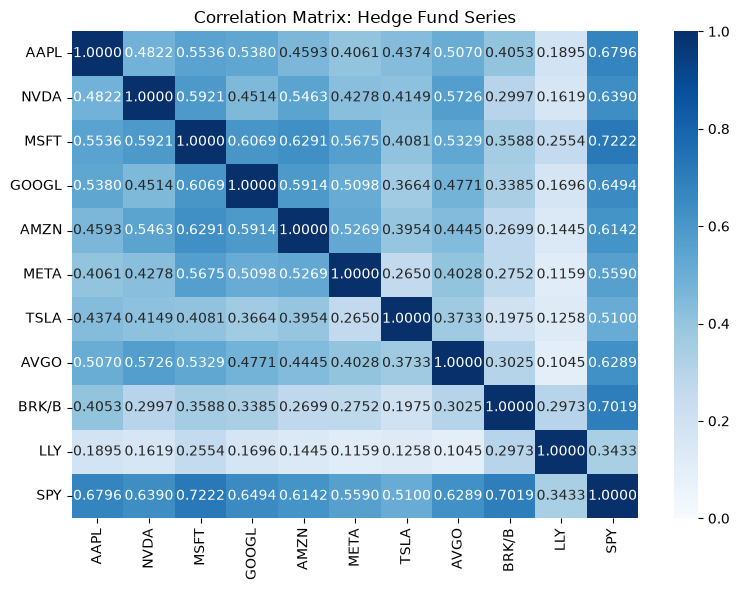

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = rets.corr()
display(corr_matrix)

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, fmt = ".4f", cmap = "Blues", vmin = 0.0, vmax = 1)
plt.title("Correlation Matrix: Hedge Fund Series")
plt.tight_layout()
plt.show()

The correlation matrix shows that all investments are positively correlated, although the strength of their correlations varies considerably. Among the individual stocks, MSFT and AMZN have the highest correlation (0.6291), suggesting that their returns tend to move closely together. In contrast, AVGO and LLY have the lowest correlation (0.1045), indicating relatively independent return movements and potentially greater diversification benefits.

Relative to SPY, MSFT exhibits the highest correlation (0.7222), while LLY has the lowest (0.3433). This suggests that LLY's returns are less closely tied to broad market movements than those of the other stocks.

**Based on this information, which investment do you anticipate will get extra weight in the portfolio, beyond what it would merit for its mean return?** 

LLY is a strong candidate to receive additional portfolio weight beyond what its standalone mean return might suggest. Despite having a relatively modest annualized mean return of 30.14%, LLY exhibits consistently low correlations with the other investments, ranging from approximately 0.10 to 0.34. Its low correlations make it particularly valuable for diversification, as including LLY can reduce overall portfolio volatility without necessarily sacrificing substantial expected returns.

Therefore, mean-variance optimization may allocate a disproportionately large weight to LLY because of its diversification benefits, even though it does not have the highest standalone return or Sharpe ratio.

**Report the maximally correlated assets and the minimally correlated assets.**

In [24]:
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)).stack()

print("Highest Correlation:")
print(corr_pairs.idxmax(), corr_pairs.max())

print("\nLowest Correlation:")
print(corr_pairs.idxmin(), corr_pairs.min())

Highest Correlation:
('MSFT', 'SPY') 0.7222349508274161

Lowest Correlation:
('AVGO', 'LLY') 0.10447767170730277


### 2.2.

Calculate the weights of the mean-variance optimized portfolio, also called the tangency portfolio.

* Display a table indexed by each investment, with the optimal weights in one column and the Sharpe ratios in another column.

* Do the investments with the best Sharpe ratios tend to get the biggest weights?

#### Note:
To estimate the optimal weights, consider using the provided function below.

In [26]:
def optimized_weights(returns,dropna=True,scale_cov=1):
    if dropna:
        returns = returns.dropna()

    covmat_full = returns.cov()
    covmat_diag = np.diag(np.diag(covmat_full))
    covmat = scale_cov * covmat_full + (1-scale_cov) * covmat_diag

    weights = np.linalg.solve(covmat,returns.mean())
    weights = weights / weights.sum()

    if returns.mean() @ weights < 0:
        weights = -weights

    return pd.DataFrame(weights, index=returns.columns)

In [28]:
tangency_weights = optimized_weights(rets).iloc[:, 0]
tangency_weights.name = "Optimal Weight"

weights_sharpe = pd.concat([tangency_weights, summary_stats["Annualized Sharpe"]], axis = 1)

display(weights_sharpe.sort_values("Optimal Weight", ascending = False))

print(f"Sum of Weights: {tangency_weights.sum():.4f}")
print(f"Largest Long: {tangency_weights.idxmax()}")
print(f"Largest Short: {tangency_weights.idxmin()}")

,Optimal Weight,Annualized Sharpe
BRK/B,1.696200,0.716352
LLY,0.905035,1.010699
NVDA,0.846346,1.420241
GOOGL,0.551347,0.939192
AVGO,0.454340,1.029681
AAPL,0.353163,0.895227
MSFT,0.301335,0.989416
TSLA,0.200492,0.754758
AMZN,0.129195,0.858063
META,0.100187,0.649108


Sum of Weights: 1.0000
Largest Long: BRK/B
Largest Short: SPY


The investments with the highest standalone Sharpe ratios do not necessarily receive the largest optimal portfolio weights. For example, NVDA has the highest annualized Sharpe ratio (1.4202), but receives only the third-largest long position (84.63%). In contrast, BRK/B receives the largest long position (169.62%) despite having a relatively low standalone Sharpe ratio (0.7164). Similarly, LLY receives the second-largest long position (90.50%), likely reflecting its relatively low correlations with the other investments and resulting diversification benefits.

Notably, the optimizer assigns SPY a substantial short position of −453.76%, while taking long positions in all ten individual stocks. This suggests that the optimizer is using SPY to hedge common market exposure while maintaining exposure to the individual stocks' expected returns.

Overall, optimal portfolio weights depend not only on standalone risk-adjusted returns but also on the covariance structure of the investments. The resulting large offsetting long and short positions illustrate how unconstrained mean-variance optimization can produce extreme allocations, particularly when assets have overlapping market exposures.

### 2.3.

Report the following performance statistics of the portfolio achieved with the optimized weights calculated above.
* mean
* volatility
* Sharpe

(Annualize all three statistics.)

In [29]:
portfolio_returns = rets.dropna() @ tangency_weights

portfolio_stats = pd.DataFrame({"Annualized Mean": [portfolio_returns.mean() * FREQ],
                                "Annualized Volatility": [portfolio_returns.std() * np.sqrt(FREQ)],
                                "Annualized Sharpe": [portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(FREQ)]}, 
                                index = ["Tangency Portfolio"])
display(portfolio_stats)

,Annualized Mean,Annualized Volatility,Annualized Sharpe
Tangency Portfolio,1.020138,0.522194,1.953559


The mean-variance optimized tangency portfolio achieves an annualized mean return of 102.01%, annualized volatility of 52.22%, and annualized Sharpe ratio of 1.9536. The portfolio's Sharpe ratio exceeds the highest standalone Sharpe ratio of 1.4202 (NVDA), demonstrating the diversification benefits of optimizing portfolio weights based on both expected returns and covariances.

However, the portfolio's high mean return and volatility are accompanied by substantial leverage, with approximately 553.76% in long positions and a −453.76% short position in SPY. While the optimized portfolio delivers superior historical risk-adjusted performance, its extreme allocations raise concerns about practical implementation, financing costs, and sensitivity to estimation error. Furthermore, these statistics are calculated in-sample and may overstate the portfolio's achievable out-of-sample performance.

### 2.4.

Try dropping the asset which had the biggest short position from the investment set. Re-run the optimization. 

In [32]:
removed_asset = tangency_weights.idxmin()
reduced_returns = rets.drop(columns = removed_asset)
print(f"Removed Asset: {removed_asset}")

new_weights = optimized_weights(reduced_returns).iloc[:, 0]
new_weights.name = "New Weight"

weight_comparison = pd.concat([tangency_weights.rename("Original Weight"), new_weights], axis = 1).fillna(0)

display(weight_comparison.sort_values("Original Weight", ascending = False))

leverage_comparison = pd.DataFrame({"Original Portfolio": [tangency_weights[tangency_weights > 0].sum(),
                                                           tangency_weights[tangency_weights < 0].sum(),
                                                           tangency_weights.abs().sum()],
                                    "New Portfolio": [new_weights[new_weights > 0].sum(), 
                                                      new_weights[new_weights < 0].sum(), 
                                                      new_weights.abs().sum()]}, 
                                    index = ["Long Exposure", "Short Exposure", "Gross Exposure"])
display(leverage_comparison)

Removed Asset: SPY


,Original Weight,New Weight
BRK/B,1.696200,0.038505
LLY,0.905035,0.430928
NVDA,0.846346,0.404944
GOOGL,0.551347,0.176540
AVGO,0.454340,0.111802
AAPL,0.353163,0.006173
MSFT,0.301335,-0.113136
TSLA,0.200492,0.023451
AMZN,0.129195,-0.034385
META,0.100187,-0.044823


,Original Portfolio,New Portfolio
Long Exposure,5.537638,1.192345
Short Exposure,-4.537638,-0.192345
Gross Exposure,10.075277,1.384690


**What do you think of these new weights compared to the original optimized weights?**

After removing SPY, which previously held the largest short position (−453.76%), the re-optimized portfolio produces substantially less extreme weights. Gross exposure decreases from 1007.53% to 138.47%, with long exposure falling from 553.76% to 119.23% and short exposure decreasing from −453.76% to −19.23%. The largest long positions are now LLY (43.09%) and NVDA (40.49%), while BRK/B's allocation falls dramatically from 169.62% to just 3.85%. Additionally, the optimizer introduces smaller short positions in MSFT (−11.31%), META (−4.48%), and AMZN (−3.44%).

**What is going on?**

The original portfolio's extreme weights likely reflect the optimizer's attempt to exploit differences in expected returns between individual stocks and SPY while hedging common market exposure. Because SPY is highly correlated with many of the individual stocks, the optimizer can take large long positions in those stocks while shorting SPY. However, unconstrained mean-variance optimization is highly sensitive to estimated returns and covariances, particularly when assets have overlapping exposures.

Removing SPY eliminates this particular hedging opportunity, resulting in a substantially less leveraged portfolio with more moderate allocations. Overall, these results demonstrate how sensitive unconstrained mean-variance optimization can be to the investment universe and its estimated covariance structure.

****